In [ ]:
import os
import random
import shutil
from collections import namedtuple
from copy import deepcopy
from typing import Any, Iterable, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from torch import Tensor
from torch_geometric.data import Data
from tqdm import tqdm

from graph_utils import prepare_traj
from pressure import compute_stress_curve, compute_stress_pressure
from utils import calc_p_ratio_box, calc_p_ratio_box_tensor

### Load interesting LJ data

In [78]:
base_dir = "/home/sergey/work/data_generation"

LJParam = namedtuple("LJParam", ["epsilon", "sigma", "cutoff"])

params = {
    LJParam(epsilon=0.01, sigma=1.0, cutoff=1.122): os.path.join(base_dir, "LJ_noisy_dataset_eps0.01_sigma1.0_cutoff1.222"),
    # LJParam(epsilon=0.01, sigma=1.0, cutoff=1.130): os.path.join(base_dir, "LJ_params_eps0.01_sigma1.0_cutoff1.13"),
    # LJParam(epsilon=0.01, sigma=1.0, cutoff=2.500): os.path.join(base_dir, "LJ_params_eps0.01_sigma1.0_cutoff2.5"),
    # LJParam(epsilon=0.10, sigma=1.0, cutoff=1.130): os.path.join(base_dir, "LJ_params_eps0.1_sigma1.0_cutoff1.13"),
    # LJParam(epsilon=0.10, sigma=1.0, cutoff=2.500): os.path.join(base_dir, "LJ_params_eps0.1_sigma1.0_cutoff2.5"),
    # LJParam(epsilon=1.00, sigma=0.9, cutoff=1.017): os.path.join(base_dir, "LJ_params_eps1.0_sigma0.9_cutoff1.017"),
}

data = {}
for interaction_params, data_dir in params.items():
    chunks = [torch.load(os.path.join(data_dir, f"chunk_{i}.pt"), weights_only=False) for i in range(len(os.listdir(data_dir)))]
    chunks = [prepare_traj(c) for c in chunks]
    data[interaction_params] = chunks

### Define functions

In [ ]:
def fit_line(function: Tensor | pd.Series | Iterable, fit_to_steps: int):

    if isinstance(function, Tensor):
        y = function[:fit_to_steps].numpy()
    elif isinstance(function, pd.Series):
        y = function[:fit_to_steps].to_numpy()
    else:
        y = function[:fit_to_steps]

    x = np.array(range(fit_to_steps))

    a, b = np.polyfit(x, y, deg=1)
    line_y = np.array([a * x + b for x in range(len(function))])
    return line_y


def get_affine_trajectory(traj: list[Data]) -> list[Data]:
    if not traj:
        return []

    a_traj = deepcopy(traj)

    init_pos = traj[0].cpu().x
    init_box = traj[0].box_tensor
    center_init = torch.mean(init_pos, dim=0)

    rel_init = init_pos - center_init

    for t in range(len(traj)):
        current_pos = traj[t].cpu().x
        current_box = traj[t].box_tensor

        lambda_x = (current_box[0] / init_box[0]).item()
        lambda_y = (current_box[1] / init_box[1]).item()

        center_current = torch.mean(current_pos, dim=0)

        affine_rel = torch.zeros_like(rel_init)
        affine_rel[:, 0] = rel_init[:, 0] * lambda_x
        affine_rel[:, 1] = rel_init[:, 1] * lambda_y

        affine_pos = affine_rel + center_current
        
        # Update
        device = traj[t].x.device
        a_traj[t].x = affine_pos.to(device)
        
 
    return a_traj


def get_non_affine_trajectory(traj: list[Data]) -> list[Data]:

    na_traj = deepcopy(traj)

    init_pos = traj[0].cpu().x
    init_box = traj[0].box_tensor
    center_init = torch.mean(init_pos, dim=0)

    for t in range(len(traj)):
        current_pos = traj[t].cpu().x
        current_box = traj[t].box_tensor
        
        # Change factor relative to t=0
        lambda_x = (current_box[0] / init_box[0]).item()
        lambda_y = (current_box[1] / init_box[1]).item()
        
        # Current center coords
        center_current = torch.mean(current_pos, dim=0)
        rel_current = current_pos - center_current
        
        # Affine subtraction
        non_affine_rel = torch.zeros_like(rel_current)
        non_affine_rel[:, 0] = rel_current[:, 0] / lambda_x
        non_affine_rel[:, 1] = rel_current[:, 1] / lambda_y

        non_affine_pos = non_affine_rel + center_init
        
        # Update
        device = traj[t].x.device
        na_traj[t].x = non_affine_pos.to(device)

        if hasattr(na_traj[t], 'box_tensor') and na_traj[t].box_tensor is not None:
            na_traj[t].box_tensor = init_box.clone().to(device)
            
    return na_traj


def plot_displacement_components(
    traj: list[Data], 
    t: int, 
    scale_vectors: float = 1.0, 
    show_edges: bool = True
):
    na_traj = get_non_affine_trajectory(traj)
    a_traj = get_affine_trajectory(traj)
    
    init_data = traj[0].cpu()
    init_pos = init_data.x.numpy()
    init_box = init_data.box_tensor.numpy()
    
    edges = init_data.edge_index.numpy()

    na_pos_t = na_traj[t].cpu().x.numpy()
    a_pos_t = a_traj[t].cpu().x.numpy()

    na_disp = na_pos_t - init_pos
    a_disp = a_pos_t - init_pos

    # Setup plotting logic
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    
    def plot_field(ax, coords, disp, edges, box_dims, title, vector_color):
        
        # Plot Edges with Minimum Image Convention (MIC)
        if show_edges and edges is not None:
            start_nodes = coords[edges[0]]
            raw_end_nodes = coords[edges[1]]
            
            # Calculate raw edge vectors
            edge_dx = raw_end_nodes[:, 0] - start_nodes[:, 0]
            edge_dy = raw_end_nodes[:, 1] - start_nodes[:, 1]
            
            # Apply MIC: wrap distances greater than half the box length
            edge_dx -= box_dims[0] * np.round(edge_dx / box_dims[0])
            edge_dy -= box_dims[1] * np.round(edge_dy / box_dims[1])
            
            # Reconstruct corrected end nodes (pointing out into the virtual cell)
            corrected_end_nodes = np.column_stack((
                start_nodes[:, 0] + edge_dx,
                start_nodes[:, 1] + edge_dy
            ))
            
            segments = np.stack([start_nodes, corrected_end_nodes], axis=1)
            lc = LineCollection(segments, colors='black', linewidths=0.5, alpha=0.3, zorder=1)
            ax.add_collection(lc)

        ax.scatter(coords[:, 0], coords[:, 1], c='lightgray', s=15, alpha=0.6, zorder=2)

        ax.quiver(
            coords[:, 0], coords[:, 1], 
            disp[:, 0], disp[:, 1], 
            angles='xy', scale_units='xy', scale=1.0 / scale_vectors, 
            color=vector_color, width=0.003, alpha=0.8, headwidth=4, zorder=3
        )

        ax.set_aspect('equal')
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.grid(True, alpha=0.2)

    plot_field(
        ax1, init_pos, a_disp, edges, init_box, 
        f"Affine Displacements ($t=0 \\rightarrow {t}$)\nScale: {scale_vectors}x", 
        vector_color='blue'
    )
    
    plot_field(
        ax2, init_pos, na_disp, edges, init_box, 
        f"Non-Affine Displacements ($t=0 \\rightarrow {t}$)\nScale: {scale_vectors}x", 
        vector_color='red'
    )

    plt.tight_layout()
    plt.show()


### Plot stress-strain curves

#### Multiple different parameters

LJParam(epsilon=0.01, sigma=1.0, cutoff=1.122)


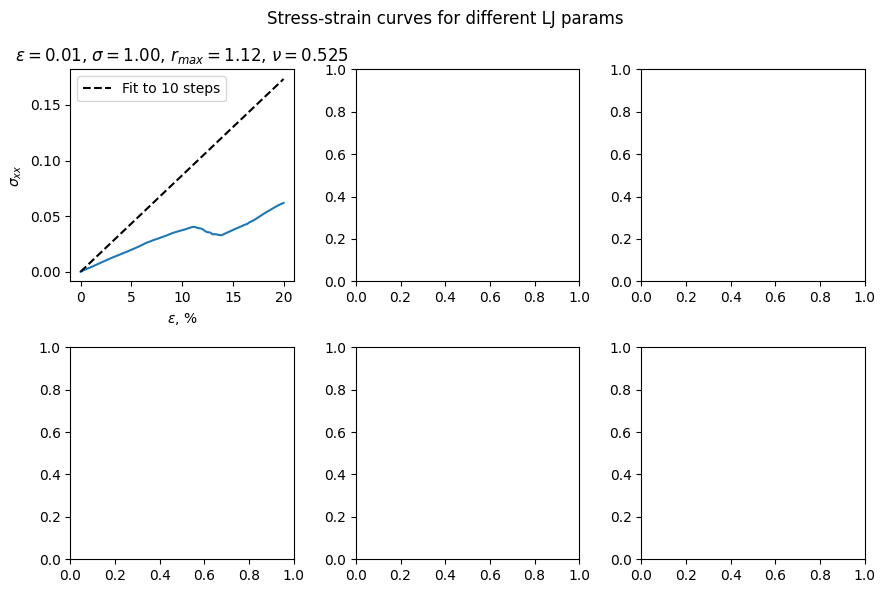

In [80]:
sim_id = 0
fig, ax = plt.subplots(2, 3, figsize=(9, 6), layout='tight')
fig.suptitle("Stress-strain curves for different LJ params") 

for idx, ((param, chunks), current_ax) in enumerate(zip(data.items(), ax.flatten())):

    print(param)

    # Pick sim by index
    sim = chunks[sim_id]
    p_ratio = calc_p_ratio_box(sim)

    # Compute strain
    sim_strain = (sim[1].box.x - sim[-1].box.x) / sim[0].box.x
    x_axis = np.linspace(0, sim_strain, len(sim)) * 100

    # Compute stress
    sim_stress = compute_stress_curve(sim, sample_stride=1)
    stress_xx = sim_stress[:, 0]
    stress_yy = sim_stress[:, 1]

    # Plot actual stress
    current_ax.plot(x_axis, stress_xx)
    # current_ax.plot(x_axis, stress_yy)
    current_ax.set_title(f"$\\epsilon = {param.epsilon:.2f}$, $\\sigma = {param.sigma:.2f}$, $r_{{max}} = {param.cutoff:.2f}$, $\\nu = {p_ratio:.3f}$")
    current_ax.set_xlabel(r"$\epsilon$, %")
    current_ax.set_ylabel(r"$\sigma_{xx}$")
    # current_ax.set_ylabel(r"$\sigma_{yy}$")
    # current_ax.set_xlim(0, 2)

    # Plot the fit
    fit_to_steps = 10
    line_y = fit_line(stress_xx, fit_to_steps)
    # line_y = fit_line(stress_yy, fit_to_steps)
    current_ax.plot(x_axis, line_y, linestyle="--", color="black", label=f"Fit to {fit_to_steps} steps")
    current_ax.legend()

plt.show()

#### Multiple sims

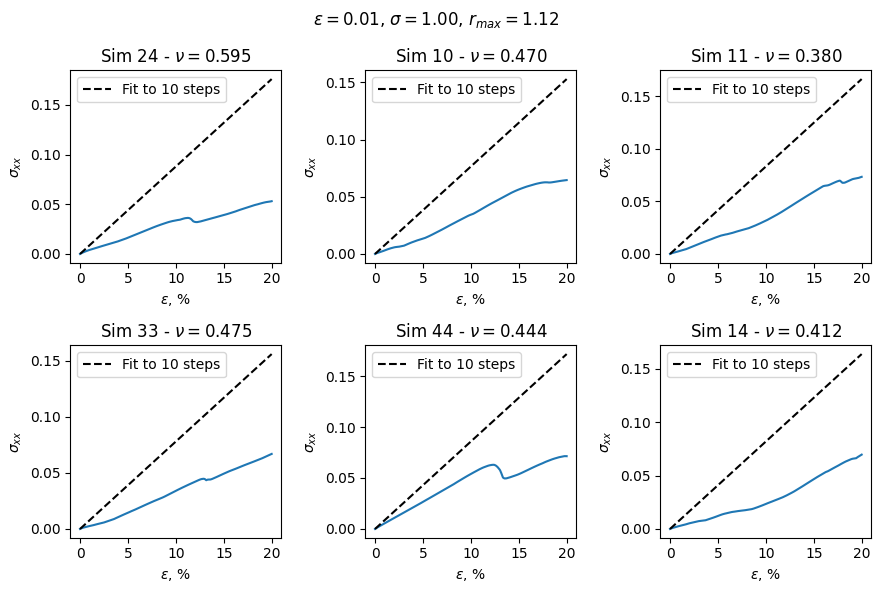

In [95]:
sim_id = 0
fig, ax = plt.subplots(2, 3, figsize=(9, 6), layout='tight')

param = sorted(data.keys())[0]
chunks = data[param]
# selected_chunks = random.sample(chunks, k=len(ax.flatten()))
selected_chunks = random.sample(range(len(chunks)), k=len(ax.flatten()))
fig.suptitle(f"$\\epsilon = {param.epsilon:.2f}$, $\\sigma = {param.sigma:.2f}$, $r_{{max}} = {param.cutoff:.2f}$") 

for idx, (chunk_id, current_ax) in enumerate(zip(selected_chunks, ax.flatten())):

    # Calculate P ratio
    sim = chunks[chunk_id]
    p_ratio = calc_p_ratio_box(sim)

    # Compute strain
    sim_strain = (sim[1].box.x - sim[-1].box.x) / sim[0].box.x
    x_axis = np.linspace(0, sim_strain, len(sim)) * 100

    # Compute stress
    sim_stress = compute_stress_curve(sim, sample_stride=1)
    stress_xx = sim_stress[:, 0]
    stress_yy = sim_stress[:, 1]

    # Plot actual stress
    current_ax.plot(x_axis, stress_xx)
    # current_ax.plot(x_axis, stress_yy)
    current_ax.set_title(f"Sim {chunk_id} - $\\nu = {p_ratio:.3f}$")
    current_ax.set_xlabel(r"$\epsilon$, %")
    current_ax.set_ylabel(r"$\sigma_{xx}$")
    # current_ax.set_ylabel(r"$\sigma_{yy}$")
    # current_ax.set_xlim(0, 2)

    # Plot the fit
    fit_to_steps = 10
    line_y = fit_line(stress_xx, fit_to_steps)
    # line_y = fit_line(stress_yy, fit_to_steps)
    current_ax.plot(x_axis, line_y, linestyle="--", color="black", label=f"Fit to {fit_to_steps} steps")
    current_ax.legend()

plt.show()

### Affine vs. Non-affine

LJParam(epsilon=0.01, sigma=1.0, cutoff=1.122)
10000


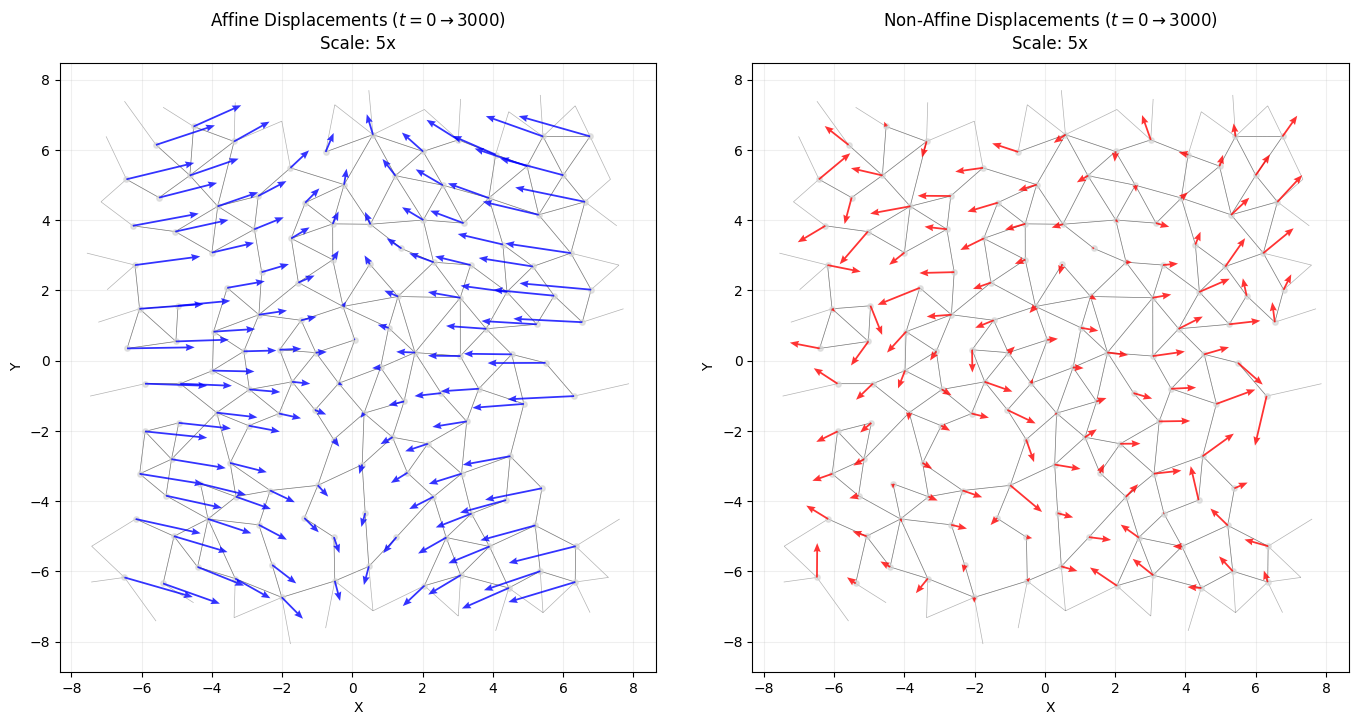

In [91]:
param = random.sample(sorted(params.keys()), k=1)[0]
chunks = data[param]
sim = random.sample(chunks, k=1)[0]
print(param)
print(len(sim))
plot_displacement_components(sim, t=3000, scale_vectors=5)

### Node trajectories

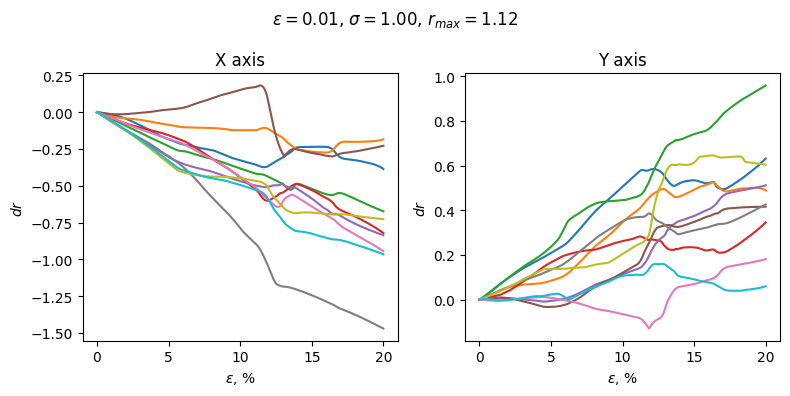

In [96]:
sim_id = 0
param = random.sample(sorted(params.keys()), k=1)[0]
sim = data[param][sim_id]

fraction = 0.05
def compute_node_trajectories(sim: List[Data], fraction: float):
    node_mask = torch.rand_like(sim[0].x[:, 0]) > (1 - fraction)
    node_trajectory_x = torch.stack([(abs(sim[j].x[node_mask][:, 0]) - abs(sim[0].x[node_mask][:, 0])) for j in range(len(sim))])
    node_trajectory_y = torch.stack([(abs(sim[j].x[node_mask][:, 1]) - abs(sim[0].x[node_mask][:, 1])) for j in range(len(sim))])
    return node_trajectory_x, node_trajectory_y

node_trajectory_x, node_trajectory_y = compute_node_trajectories(sim, fraction)

fig, ax = plt.subplots(1, 2, figsize=(8, 4), layout="tight")
fig.suptitle((f"$\\epsilon = {param.epsilon:.2f}$, $\\sigma = {param.sigma:.2f}$, $r_{{max}} = {param.cutoff:.2f}$"))

sim_strain = (sim[1].box.x - sim[-1].box.x) / sim[0].box.x
x_axis = np.linspace(0, sim_strain, len(sim)) * 100
max_steps = -1

ax[0].plot(x_axis[:max_steps], node_trajectory_x[:max_steps])
ax[0].set_title('X axis')
ax[0].set_ylabel("$dr$")
ax[0].set_xlabel(r"$\epsilon$, %")
# ax[0].set_xlim(0, 1)

ax[1].plot(x_axis[:max_steps], node_trajectory_y[:max_steps])
ax[1].set_title('Y axis')
ax[1].set_ylabel("$dr$")
ax[1].set_xlabel(r"$\epsilon$, %")
# ax[1].set_xlim(0, 1)

plt.show()